In [1]:
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import os
import matplotlib.pyplot as plt
import numpy as np
from scipy import fftpack as fft
import cv2
import pandas as pd
import random
import scipy
import torch
import torchvision.transforms as T
from PIL import Image, ImageOps
from torch import nn
# from timm.models import convnext, maxxvit
import timm
from timm.scheduler.cosine_lr import CosineLRScheduler
import tensorflow as tf
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report
import json
import warnings
from tqdm import tqdm
import gc

2025-03-10 19:52:45.751739: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-10 19:52:45.751874: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-10 19:52:45.889283: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
df = pd.read_csv("/kaggle/input/signal-pose-prediction/train.csv").fillna(-1)
df["class"].value_counts()

class
6    121
4    116
3    111
5    107
1     99
0     50
2     43
Name: count, dtype: int64

<Axes: xlabel='class'>

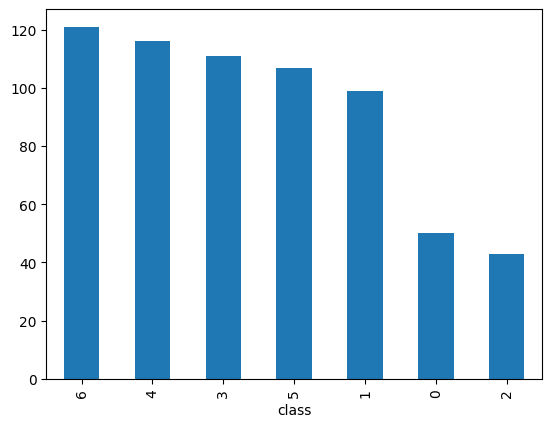

In [3]:
df["class"].value_counts().plot(kind="bar")

In [4]:
random.seed(42)

std = np.std(df["class"].value_counts().to_numpy())
prob = torch.nn.Softmax(dim=0)(
    torch.tensor(df["class"].value_counts().to_numpy() / std, dtype=torch.float))
test_size = 0.1
nums_test_sample = int(len(df) * test_size)
val_choices = random.choices(list(df["class"].value_counts().to_dict().keys()), weights=prob, k=nums_test_sample)

vals = []
train_df = df.copy()
for choice in val_choices:
    index = train_df[train_df["class"] == choice].sample(1, random_state=42).index[0]
    vals.append(df.iloc[index].to_numpy())
    train_df = train_df.drop(index)

In [5]:
train_df.reset_index(drop=True, inplace=True)
val_df = pd.DataFrame(vals, columns=["id", "class"])
val_df.reset_index(drop=True, inplace=True)

In [6]:
noise_threshold = -120

def range_frequency(data):
    # Process one frame at a time to save memory
    rd = np.fft.fft(data, axis=0)
    rd = np.fft.fftshift(rd, axes=0)
    rd = np.abs(rd)
    np.log10(rd + 1e-10, out=rd)  # In-place operation
    rd *= 20  # In-place multiplication
    rd[rd < noise_threshold] = noise_threshold
    return rd

def duplicate_range(data, n_dup=5):
    # More memory-efficient implementation using a rolling window
    total_frames = data.shape[0]
    if total_frames <= n_dup:
        return np.expand_dims(data, axis=0)
    
    result_length = total_frames - n_dup + 1
    result = np.zeros((result_length, n_dup, data.shape[1]), dtype=data.dtype)
    
    for i in range(result_length):
        result[i] = data[i:i+n_dup]
    
    return result

def process_and_save_image(file_path, out_dir, row_id, height, width, dpi):
    # Load only the needed channel
    sample_img = np.load(os.path.join(file_path, row_id + ".npy"))[:,:,1]
    
    # Truncate if necessary
    if sample_img.shape[0] > 2560:
        sample_img = sample_img[-2560:]
    
    # Apply Euler transformation
    distance_img = sample_img * np.exp(1j * 0.21)
    
    # Get magnitude and free memory
    np.abs(distance_img, out=distance_img)
    
    # Apply duplicate range
    distance_img = duplicate_range(distance_img, 40)
    
    # Process frames one by one to save memory
    processed_frames = []
    for i in range(distance_img.shape[0]):
        frame = range_frequency(distance_img[i])
        processed_frames.append(frame)
        
    # Stack and reshape
    distance_img = np.stack(processed_frames)
    distance_img = distance_img.reshape(distance_img.shape[0]*distance_img.shape[1], distance_img.shape[2]).real
    
    # Create and save image
    fig, axs = plt.subplots(1, 1, figsize=(width/dpi, height/dpi))
    axs.imshow(np.transpose(distance_img), aspect='auto')
    axs.axis('off')
    
    os.makedirs(out_dir, exist_ok=True)
    fig.savefig(os.path.join(out_dir, row_id + ".jpg"), dpi=100, bbox_inches='tight', pad_inches=0)
    plt.close(fig)
    
    # Force garbage collection
    del sample_img, distance_img, processed_frames
    gc.collect()

In [7]:
# Constants
file_path = "/kaggle/input/signal-pose-prediction/train/train"
height = 384 // 1.4
width = 384
dpi = 100

In [8]:
# Process training data
out_dir = "train_images"
for idx, row in tqdm(train_df.iterrows()):
    process_and_save_image(file_path, out_dir, row["id"], height, width, dpi)

583it [18:53,  1.94s/it]


In [9]:
# Process validation data
out_dir = "val_images"
for idx, row in tqdm(val_df.iterrows()):
    process_and_save_image(file_path, out_dir, row["id"], height, width, dpi)

64it [01:53,  1.77s/it]


In [10]:
# file_path = "/kaggle/input/signal-pose-prediction/train/train"
# out_dir = "train_images"

# height = 384 // 1.4
# width = 384
# dpi = 100

# for idx, row in tqdm(train_df.iterrows()):    
#     sample_img = np.load(os.path.join(file_path, row["id"] + ".npy"))[:,:,1]
#     # print("Original shape:", sample_img.shape)
    
#     if sample_img.shape[0] > 2560:
#         sample_img = sample_img[-2560:]

#     distance_img = sample_img
#     distance_img = euler(distance_img, 0.21)
#     distance_img = duplicate_range(np.abs(distance_img), 40)
#     # print("After duplicate_range:", distance_img.shape)
#     distance_img = range_frequency(distance_img)
#     # print("After range_frequency:", distance_img.shape)
#     distance_img = distance_img.reshape(distance_img.shape[0]*distance_img.shape[1], distance_img.shape[2]).real
        
#     fig, axs = plt.subplots(1, 1, figsize=(width/dpi, height/dpi))
#     axs.imshow(np.transpose(distance_img), aspect='auto')         # : EDIT HERE : select your camp
#     axs.axis('off')
    
#     os.makedirs(out_dir, exist_ok=True)
    
#     fig.savefig(os.path.join(out_dir, row["id"] + ".jpg"), dpi=100, bbox_inches='tight', pad_inches=0)
#     plt.close(fig)

In [11]:
# file_path = "/kaggle/input/signal-pose-prediction/train/train"
# out_dir = "val_images"

# height = 384 // 1.4
# width = 384
# dpi = 100

# for idx, row in tqdm(val_df.iterrows()):    
#     sample_img = np.load(os.path.join(file_path, row["id"] + ".npy"))[:,:,1]
    
#     if sample_img.shape[0] > 2560:
#         sample_img = sample_img[-2560:]

#     distance_img = sample_img
#     distance_img = euler(distance_img, 0.21)
#     distance_img = duplicate_range(np.abs(distance_img), 40)
#     distance_img = range_frequency(distance_img)
#     distance_img = distance_img.reshape(distance_img.shape[0]*distance_img.shape[1], distance_img.shape[2]).real
        
#     fig, axs = plt.subplots(1, 1, figsize=(width/dpi, height/dpi))
#     axs.imshow(np.transpose(distance_img), aspect='auto')  
#     axs.axis('off')
    
#     os.makedirs(out_dir, exist_ok=True)
    
#     fig.savefig(os.path.join(out_dir, row["id"] + ".jpg"), dpi=100, bbox_inches='tight', pad_inches=0)
#     plt.close(fig)

In [12]:
img_size = (224, 224)

transforms = {
    "train": T.Compose([
        T.Resize(img_size, interpolation=T.InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=torch.tensor([0.4850, 0.4560, 0.4060]), std=torch.tensor([0.2290, 0.2240, 0.2250]))
    ]),
    "test": T.Compose([
        T.Resize(img_size, interpolation=T.InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=torch.tensor([0.4850, 0.4560, 0.4060]), std=torch.tensor([0.2290, 0.2240, 0.2250]))
    ]),
    "aug": T.Compose([
        T.RandomResizedCrop(img_size, scale=(0.5, 0.8)),
        T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.1)),
        T.Resize(img_size, interpolation=T.InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=torch.tensor([0.4850, 0.4560, 0.4060]), std=torch.tensor([0.2290, 0.2240, 0.2250]))
    ]),
}

In [13]:
class ImageDataset(Dataset):
    def __init__(self, dataframe, src, size, transforms):
        self.dataframe = dataframe
        self.src = src
        self.size = size 
        self.transforms = transforms

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        path = os.path.join(self.src, row['id'] + ".jpg")
        image = Image.open(path).convert("RGB")
        
        image = image.resize((self.size, self.size // 2))
        image = ImageOps.pad(image, (self.size, self.size))
        image = self.transforms(image)

        return image, row["class"]

In [14]:
np.random.seed(42)
g = torch.manual_seed(42)

In [15]:
train_dataset = ImageDataset(train_df, "train_images", 384, transforms["train"])
val_dataset = ImageDataset(val_df, "val_images", 384, transforms["test"])
aug_dataset = ImageDataset(train_df, "train_images", 384, transforms["aug"])

In [16]:
# Hyper parameter from sweep results
n_epochs = 20
batch_size = 8
num_print_log = 2
num_accumulate = 4
learning_rate = 0.000577998135640768

device = "cuda"

model = timm.create_model(
    "maxvit_rmlp_base_rw_224", 
    pretrained=True, 
    num_classes=7
).to(device)

criterion2 = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
schedule = timm.scheduler.create_scheduler_v2(optimizer, num_epochs=n_epochs)[0]

train_loader = DataLoader(
    torch.utils.data.ConcatDataset([train_dataset, aug_dataset]),
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    generator=g
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=4
)
max_acc = 0

for epoch in range(n_epochs):
    print('Epoch:', epoch + 1)
    progbar = tf.keras.utils.Progbar(len(train_loader))
    num_updates = epoch * len(train_loader)
    model.train()

    training_loss = []
    training_acc = []

    num_updates = epoch * len(train_loader)

    for idx, (x, cls) in enumerate(train_loader):
        x = x.to(device).float()
        cls = cls.to(device)
#         optimizer.zero_grad()

        logit = model(x)

        loss = criterion2(logit, cls)
        training_loss.append(loss.item())
        loss.backward()

        # === Gradient Accumulation === #
        if ((idx + 1) % num_accumulate == 0) or (idx + 1 == len(train_loader)):
            optimizer.step()
            schedule.step_update(num_updates=num_updates)
            optimizer.zero_grad()
        # ============================= #

        _, predicted = logit.max(1)
        acc = predicted.eq(cls).sum().item() / cls.size(0)
        training_acc.append(acc)
#         optimizer.step()
        printlog = [
            ('loss2', loss.cpu().detach().numpy()),
            ('acc', acc)
        ]


#         if idx % (len(train_loader) // num_print_log) == 0:
#             wandb.log(
#                 {"accuracy": sum(training_acc) / len(training_acc),
#                  "train loss": sum(training_loss) / len(training_loss)})

        progbar.update(idx + 1, printlog)
    schedule.step(epoch + 1)    

    model.eval()
    progbar = tf.keras.utils.Progbar(len(val_loader))
    predict = []
    with torch.no_grad():
        val_acc = []
        for idx, (x, cls) in enumerate(val_loader):
            x = x.to(device).float()
            cls = cls.to(device)
            logit = model(
                x  # [:, 0]
            )

            _, predicted = logit.max(1)
            acc = predicted.eq(cls).sum().item() / cls.size(0)
            val_acc.append(acc)
            progbar.update(idx + 1, [('val_acc', acc)])

#         wandb.log({"val_accuracy": sum(val_acc) / len(val_acc)})
        torch.save(model.state_dict(), f"model_{epoch + 1}.pt")

/opt/conda/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /usr/local/src/pytorch/aten/src/ATen/native/TensorShape.cpp:3526.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


model.safetensors:   0%|          | 0.00/465M [00:00<?, ?B/s]

Epoch: 1
64/64 [==============================] - 5s 72ms/step - val_acc: 0.4219
Epoch: 2
64/64 [==============================] - 5s 75ms/step - val_acc: 0.5156
Epoch: 3
64/64 [==============================] - 5s 71ms/step - val_acc: 0.7188
Epoch: 4
64/64 [==============================] - 5s 72ms/step - val_acc: 0.6094
Epoch: 5
64/64 [==============================] - 5s 73ms/step - val_acc: 0.8438
Epoch: 6
64/64 [==============================] - 5s 73ms/step - val_acc: 0.6562
Epoch: 7
64/64 [==============================] - 5s 72ms/step - val_acc: 0.8750
Epoch: 8
64/64 [==============================] - 5s 75ms/step - val_acc: 0.8594
Epoch: 9
64/64 [==============================] - 5s 73ms/step - val_acc: 0.7656
Epoch: 10
64/64 [==============================] - 5s 74ms/step - val_acc: 0.9375
Epoch: 11
64/64 [==============================] - 5s 73ms/step - val_acc: 0.8594
Epoch: 12
64/64 [==============================] - 5s 73ms/step - val_acc: 0.9062
Epoch: 13
64/64 [========

In [17]:
test_df = pd.read_csv("/kaggle/input/signal-pose-prediction/sample_submission.csv")
test_df.fillna(-1, inplace=True)

In [18]:
file_path = "/kaggle/input/signal-pose-prediction/test/test"
csv_path = "/kaggle/input/signal-pose-prediction/train.csv"

# Process test data
out_dir = "test_images"
for idx, row in tqdm(test_df.iterrows()):
    process_and_save_image(file_path, out_dir, row["id"], height, width, dpi)

164it [04:58,  1.82s/it]


In [19]:
test_dataset = ImageDataset(test_df, "test_images", 384, transforms["test"])
test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=4
)

In [20]:
for x, y in test_loader:
    print(y.item())

6.0
4.0
2.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0
-1.0


In [21]:
# best_model = timm.models.maxxvit.maxvit_rmlp_base_rw_224(pretrained=True, num_classes=7).to(device)
# best_model.load_state_dict(torch.load("model_14.pt"))
# best_model.eval()
best_model = model

In [22]:
progbar = tf.keras.utils.Progbar(len(test_loader))
predict = []

with torch.no_grad():
    for idx, (x, cls) in enumerate(test_loader):
        cls = int(cls.item())
        if cls > -1:
            predict.append(cls)
            continue
        x = x.to(device).float()
        logit = best_model(x)

        _, predicted = logit.max(1)
        predict.extend(predicted.cpu().detach().numpy().tolist())
        
df = test_df.copy()
df['class'] = predict
df.to_csv(f'submission.csv', index=False)